# Load libraries


In [15]:
import numpy as np
import matplotlib.pyplot as PLT

from scipy.special import softmax,logsumexp

import os
import IPython

import tensorflow as tf
from tensorflow import keras

import keras.backend as K

from tensorflow.python.ops import array_ops, math_ops, state_ops, control_flow_ops

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential


# Download data

In [16]:

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import cifar10

# Training / validation data + labels
if False:
   (x_train, y_train), (x_valid, y_valid) = mnist.load_data()
else:
   (x_train, y_train), (x_valid, y_valid) = cifar10.load_data()
    
print('Shape (training data):', x_train.shape, 'Labels:',y_train.shape)
print('Shape (valid/testing data):', x_valid.shape)


Shape (training data): (50000, 32, 32, 3) Labels: (50000, 1)
Shape (valid/testing data): (10000, 32, 32, 3)


#### Visualization of a random element

Shape: (32, 32, 3) label: [7]


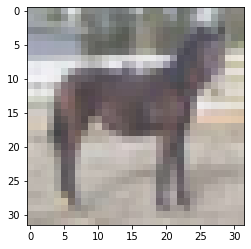

In [17]:
k = np.random.randint(0,x_train.shape[0])
    
PLT.imshow( x_train[k])
print('Shape:',x_train[k].shape, 'label:', y_train[k])


### Data pre-processing (normalization, etc.)

In [18]:
def stdPreproc(dIn,L=255.0, flagNorm=True, flagMean=True):

    dIn = dIn.astype("float")
    
    if flagNorm:
       dIn = dIn/L

    if flagMean:
       mean = np.mean(dIn, axis = 0)
       dIn -= mean
    
    return(dIn)

x_train = stdPreproc(x_train)
x_valid = stdPreproc(x_valid)

#### Data vectorization

In [19]:
trFlag = False

if trFlag:
   x_train = np.transpose( x_train.reshape(x_train.shape[0], int(x_train.size/x_train.shape[0]) ) )
   x_valid = np.transpose( x_valid.reshape(x_valid.shape[0], int(x_valid.size/x_valid.shape[0]) ) )
   # NOTE: in order to be consistant with lectures, then these matrices must be transpose
else:
   # TF does not use transpose
   x_train = x_train.reshape(x_train.shape[0], int(x_train.size/x_train.shape[0]) ) 
   x_valid = x_valid.reshape(x_valid.shape[0], int(x_valid.size/x_valid.shape[0]) ) 

print(x_train.shape)
print(x_valid.shape)


(50000, 3072)
(10000, 3072)


# TF based examples

In [20]:
print(y_train.shape)
print(y_valid.shape)

num_categories = 10

y_train = keras.utils.to_categorical(y_train, num_categories)
y_valid = keras.utils.to_categorical(y_valid, num_categories)

print(y_train.shape)
print(y_valid.shape)

History = {}

(50000, 1)
(10000, 1)
(50000, 10)
(10000, 10)


## TF built-in

In [21]:
K.clear_session()

model_tf = Sequential()

model_tf.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_tf.add(Dense(units = 10, activation='softmax'))

model_tf.summary()

model_tf.compile(loss='categorical_crossentropy', metrics=['accuracy'])
history_tf = model_tf.fit(
    x_train, y_train, epochs=50, verbose=1, validation_data=(x_valid, y_valid)
)

History['TF defualt'] = history_tf

 

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
1563/1563 [==============================] - 26s 17ms/step - loss: 1.7631 - accuracy: 0.4067 - val_loss: 1.5774 - val_accuracy: 0.4535
Epoch 2/50
1563/1563 [==============================] - 25s 16ms/step - loss: 1.4789 - accuracy: 0.4886 - val_loss: 1.5244 - val_accuracy: 0.4749
Epoch 3/50
1563/1563 [==============================] - 26s 17ms/step - loss: 1.3722 - accuracy: 0.5280 - val_loss: 1.4501 - val_accuracy: 0.5088
Epoch 4/50
1563/1563 [==============================] - 26s 17ms/step 

## TF adam

In [22]:
K.clear_session()


model_ad = Sequential()

model_ad.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_ad.add(Dense(units = 10, activation='softmax'))

model_ad.summary()

model_ad.compile(loss='categorical_crossentropy', metrics=['accuracy'], 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
history_ad = model_ad.fit(
    x_train, y_train, epochs=50, verbose=1, validation_data=(x_valid, y_valid)
)

History['TF ADAM'] = history_ad


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
1563/1563 [==============================] - 12s 8ms/step - loss: 1.6991 - accuracy: 0.4201 - val_loss: 1.5030 - val_accuracy: 0.4745
Epoch 2/50
1563/1563 [==============================] - 12s 8ms/step - loss: 1.4646 - accuracy: 0.4888 - val_loss: 1.4589 - val_accuracy: 0.4918
Epoch 3/50
1563/1563 [==============================] - 12s 8ms/step - loss: 1.3746 - accuracy: 0.5254 - val_loss: 1.5011 - val_accuracy: 0.4892
Epoch 4/50
1563/1563 [==============================] - 13s 8ms/step - lo

## Plot summary

{'TF defualt': <tensorflow.python.keras.callbacks.History object at 0x7fb3b80550d0>, 'TF ADAM': <tensorflow.python.keras.callbacks.History object at 0x7fb3178f6690>}
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


Text(0.5, 0, 'epoch')

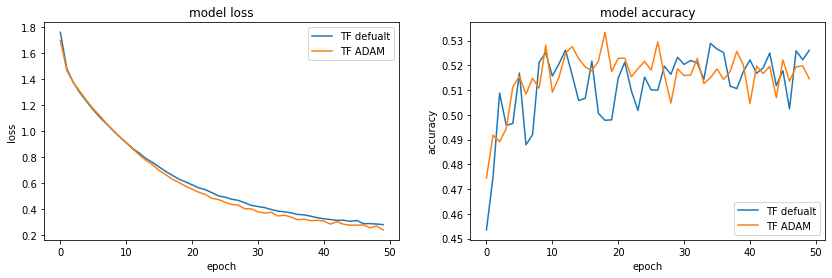

In [23]:
print(History)
print(History['TF defualt'].history.keys())

PLT.figure(figsize=(14, 4))

PLT.subplot(121)
# summarize history for loss

for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['loss'],label=r'{0}'.format(keys))

PLT.legend(loc='upper right')    
PLT.title('model loss')
PLT.ylabel('loss')
PLT.xlabel('epoch')
    
PLT.subplot(122)
# summarize history for accuracy

for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['val_accuracy'],label=r'{0}'.format(keys))

PLT.legend(loc='lower right')    
PLT.title('model accuracy')
PLT.ylabel('accuracy')
PLT.xlabel('epoch')


## Own solver

In [24]:
class HoSGD_sgd(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, 
                 name="HoSGD_sgd", **kwargs):
        """Call super().__init__() """
        super().__init__(name, **kwargs)
        self._set_hyper("learning_rate", kwargs.get("lr", learning_rate)) # handle lr=learning_rate
        
    def _create_slots(self, var_list):
        """Slots.
        """
        
    @tf.function
    def _resource_apply_dense(self, grad, var):
        """Main routine
        """
        var_dtype = var.dtype.base_dtype

        # Get alpha0
        #alpha0 = self._get_hyper('learning_rate', var_dtype)
        alpha = self._decayed_lr(var_dtype)
        
        # GD step
        #new_var = var - alpha0 * grad
        new_var = var - alpha * grad 
        
        # save 
        var.assign(new_var)
        
        
    def _resource_apply_sparse(self, grad, var):
        raise NotImplementedError

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "learning_rate": self._serialize_hyperparameter("learning_rate"),
        }
        
class HoSGD_adam(keras.optimizers.Optimizer):
    def __init__(self, learning_rate=0.001, 
                 gamma1=0.9, gamma2=0.999, epsilon=1e-7,
                 name="HoSGD_adam", **kwargs):
        """Call super().__init__() """
        super().__init__(name, **kwargs)
        self._set_hyper("learning_rate", kwargs.get("lr", learning_rate)) # handle lr=learning_rate
        self._set_hyper('gamma1', gamma1)
        self._set_hyper('gamma2', gamma2)
        self._set_hyper('epsilon', epsilon)
        
    def _create_slots(self, var_list):
        """Slots.
        """
        for var in var_list:
            self.add_slot(var, 'v')
        for var in var_list:
            self.add_slot(var, 'T')
        #self._updates_per_iter = len(var_list)
        
    def _resource_apply_dense(self, grad, var):
        """Main routine
        """
        var_dtype = var.dtype.base_dtype

        # iteration
        k   = math_ops.cast(self.iterations+1, tf.float32)
        
        # epsilon
        epsilon = array_ops.identity(self._get_hyper('epsilon', var_dtype))
        
        # Get gamma
        gamma1 = array_ops.identity(self._get_hyper('gamma1', var_dtype))
        gamma2 = array_ops.identity(self._get_hyper('gamma2', var_dtype))
        gamma1Pow = math_ops.pow(gamma1, k)
        gamma2Pow = math_ops.pow(gamma2, k)
        
        # Adam's var
        v = self.get_slot(var, 'v')
        T = self.get_slot(var, 'T')
        
        TCur = state_ops.assign(T, gamma1 * T + (1.0 - gamma1) * grad,
                                use_locking=self._use_locking)
        vCur = state_ops.assign(v, gamma2 * v + (1.0 - gamma2) * math_ops.square(grad),
                                use_locking=self._use_locking)
        
        # Get alpha
        alpha = self._decayed_lr(var_dtype)
        
        # weights
        w = ( math_ops.sqrt(1 - gamma2Pow) / (1 - gamma1Pow) ) / (math_ops.sqrt(vCur) + epsilon)
        
        
        # GD step
        new_var = state_ops.assign_sub(var, alpha * w * TCur, use_locking=self._use_locking)
        
        # save 
        updates = [new_var, TCur, vCur]
        return control_flow_ops.group(*updates)
        
        
    def _resource_apply_sparse(self, grad, var):
        raise NotImplementedError

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "learning_rate": self._serialize_hyperparameter("learning_rate"),
        }


In [25]:
History_own = {}

## HoSGD_sgd

In [26]:
K.clear_session()


model_own = Sequential()

model_own.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_own.add(Dense(units = 10, activation='softmax'))

model_own.summary()

model_own.compile(loss='categorical_crossentropy', metrics=['accuracy'], 
              optimizer=HoSGD_sgd(learning_rate=0.001))
history_own = model_own.fit(
    x_train, y_train, epochs=10, verbose=1, validation_data=(x_valid, y_valid)
)

History_own['HoSGD sgd'] = history_own


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1563/1563 [==============================] - 10s 6ms/step - loss: 2.0832 - accuracy: 0.2602 - val_loss: 1.9611 - val_accuracy: 0.3161
Epoch 2/10
1563/1563 [==============================] - 10s 6ms/step - loss: 1.9070 - accuracy: 0.3367 - val_loss: 1.8606 - val_accuracy: 0.3577
Epoch 3/10
1563/1563 [==============================] - 10s 6ms/step - loss: 1.8302 - accuracy: 0.3677 - val_loss: 1.8024 - val_accuracy: 0.3752
Epoch 4/10
1563/1563 [==============================] - 9s 6ms/step - los

## HoSGD_adam

In [27]:
K.clear_session()


model_ownAd = Sequential()

model_ownAd.add(Dense(units=512, activation='relu', input_shape=(3072,)))
model_ownAd.add(Dense(units = 10, activation='softmax'))

model_ownAd.summary()

model_ownAd.compile(loss='categorical_crossentropy', metrics=['accuracy'], 
              optimizer=HoSGD_adam(learning_rate=0.001))
history_ownAd = model_ownAd.fit(
    x_train, y_train, epochs=10, verbose=1, validation_data=(x_valid, y_valid)
)

History_own['HoSGD adam'] = history_ownAd


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 512)               1573376   
_________________________________________________________________
dense_1 (Dense)              (None, 10)                5130      
Total params: 1,578,506
Trainable params: 1,578,506
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.6906 - accuracy: 0.4205 - val_loss: 1.5054 - val_accuracy: 0.4710
Epoch 2/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.4618 - accuracy: 0.4919 - val_loss: 1.4800 - val_accuracy: 0.4833
Epoch 3/10
1563/1563 [==============================] - 26s 16ms/step - loss: 1.3734 - accuracy: 0.5246 - val_loss: 1.4478 - val_accuracy: 0.5030
Epoch 4/10
1563/1563 [==============================] - 26s 16ms/step 

## Plot summary -- TF + own

Text(0.5, 0, 'epoch')

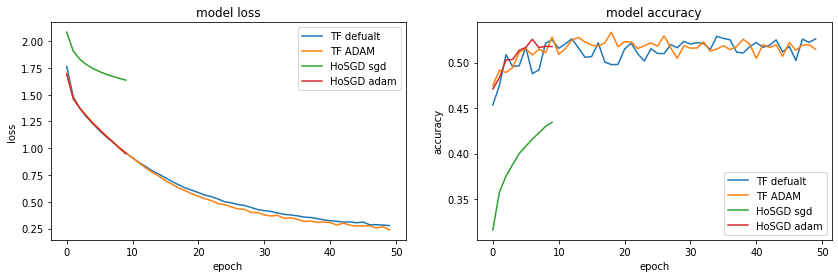

In [28]:

# summarize history for loss
PLT.figure(figsize=(14, 4))

PLT.subplot(121)
for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['loss'],label=r'{0}'.format(keys))
for k, keys in enumerate(History_own): 
    PLT.plot(History_own[keys].history['loss'],label=r'{0}'.format(keys))

PLT.legend(loc='upper right')    
PLT.title('model loss')
PLT.ylabel('loss')
PLT.xlabel('epoch')

PLT.subplot(122)
for k, keys in enumerate(History): 
    PLT.plot(History[keys].history['val_accuracy'],label=r'{0}'.format(keys))
for k, keys in enumerate(History_own): 
    PLT.plot(History_own[keys].history['val_accuracy'],label=r'{0}'.format(keys))

PLT.legend(loc='lower right')    
PLT.title('model accuracy')
PLT.ylabel('accuracy')
PLT.xlabel('epoch')
